<a href="https://colab.research.google.com/github/joyumoh/Order_Status_Prediction/blob/main/Order_Status_Prediction_For_Retail_Business.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Introduction**

E-commerce businesses face the significant challenge of managing unsuccessful orders, such as cancellations and returns. This project aims to develop a machine learning model to predict customer order statuses (Delivered, Cancelled, Returned) using transactional, customer, and operational data.

**Benefits of predicting order outcomes:**
- Reduce operational losses
- Improve delivery efficiency
- Detect risky transactions early
- Enhance customer satisfaction
- Optimize inventory and logistics

This project will follow a standard data science workflow: Data Understanding, Data Cleaning & Preprocessing, Exploratory Data Analysis (EDA), Data Visualization, and Predictive Modeling.

**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Train test split
from sklearn.model_selection import train_test_split

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
# Load dataset
df = pd.read_excel('/content/Online-Store-Orders.xlsx')

# Display first 5 rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Uderstanding The Dataset

In [3]:
# Number of rows and columns
df.shape

# Data Types
df.dtypes

# Data Iformation
df.info()

# Describing The Dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# Dataset Understanding

The dataset contains transactional information from an online retail store.

Each row represents a customer order and includes details such as:
- Customer information
- Product details
- Payment methods
- Order quantities
- Pricing
- Shipping information
- Order status

The target variable for this project is:
`OrderStatus`

This variable contains multiple classes:
- Delivered
- Cancelled
- Returned

The project aims to predict these order outcomes using machine learning.

## Data Cleaning And Preprocessing


In [4]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Missing values count
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [6]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [7]:
# Filling missing CouponCode
df['CouponCode'] = df['CouponCode'].fillna('Unknown')

In [8]:
# Converting date column
df['Date'] = pd.to_datetime(df['Date'])

## Initial EDA

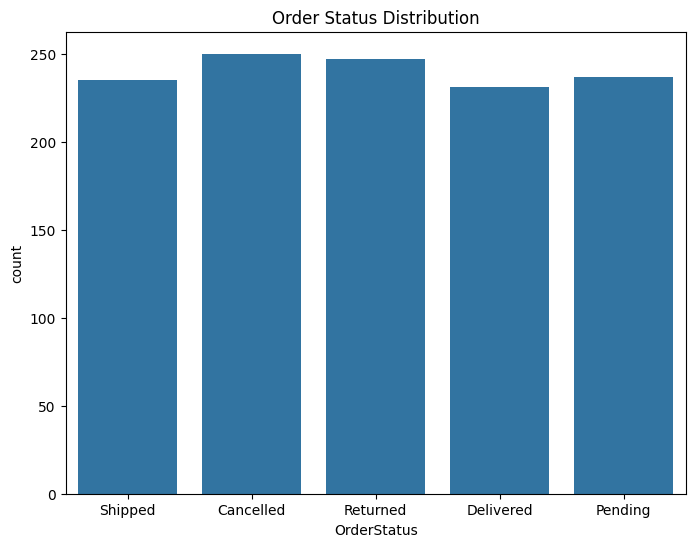

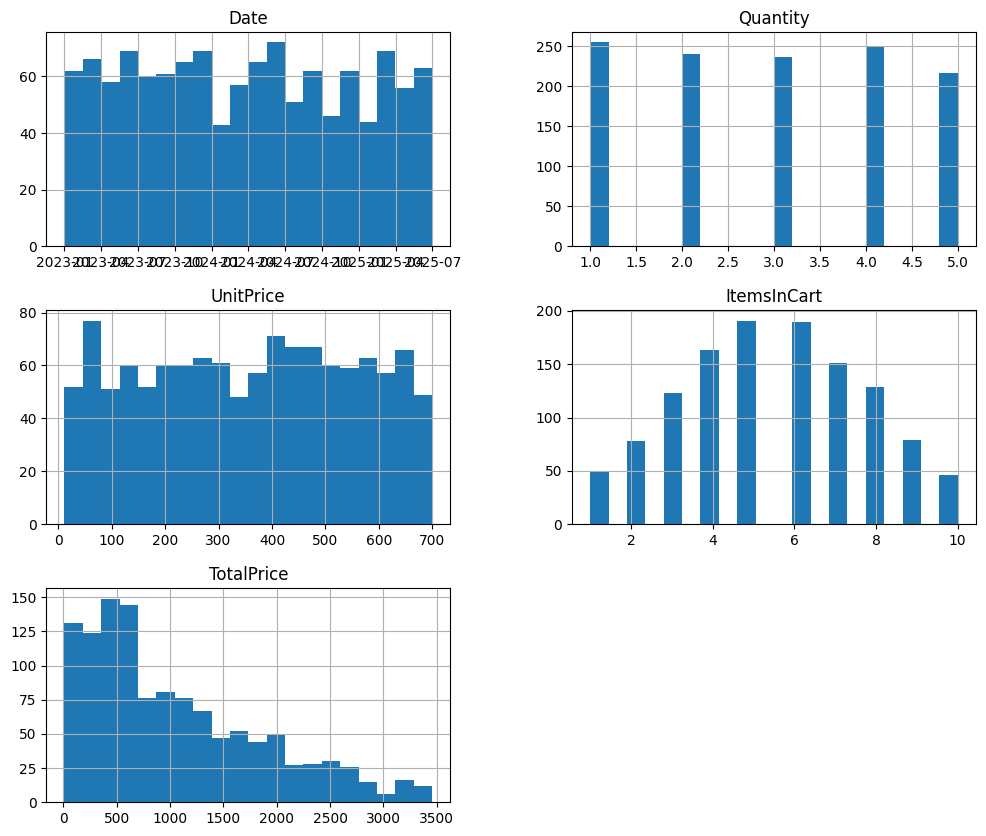

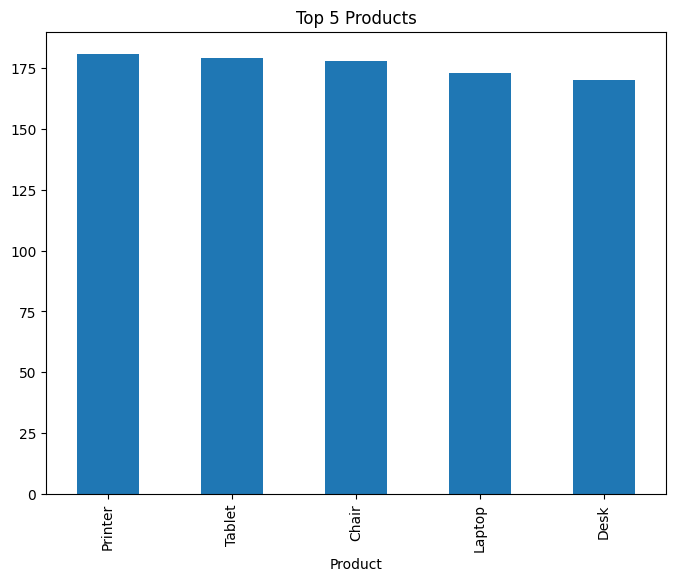

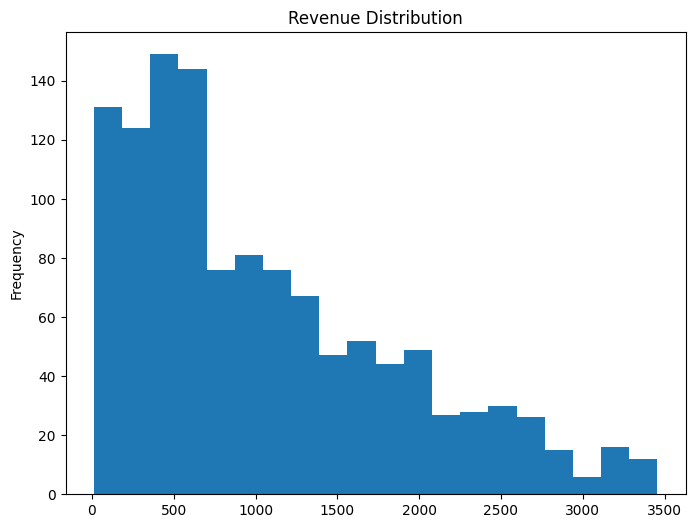

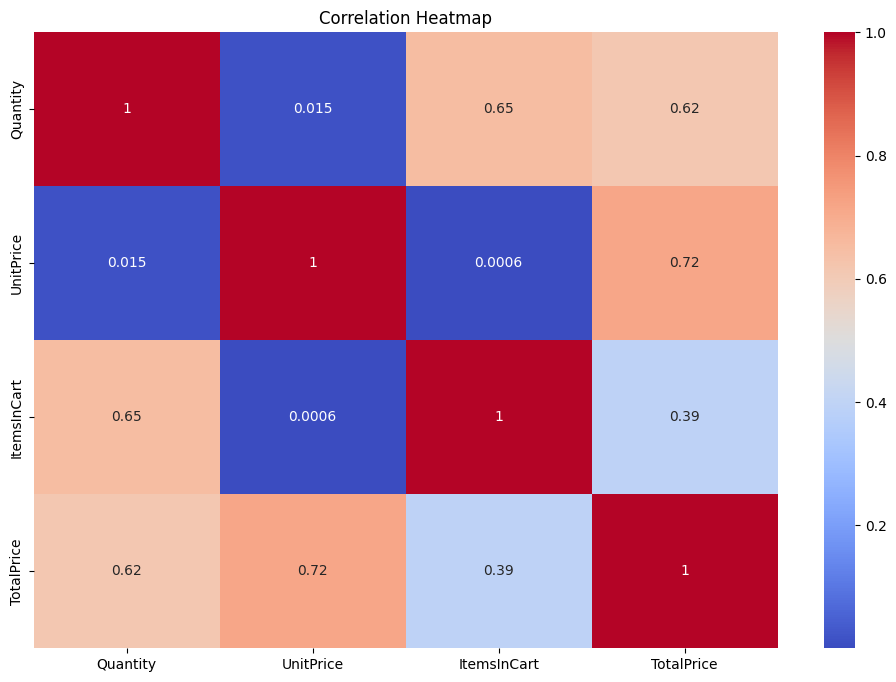

In [9]:
# Target Variable Distribution
plt.figure(figsize=(8, 6)) # Set figure size
sns.countplot(x='OrderStatus', data=df)
plt.title("Order Status Distribution")
plt.show()

# Numerical Features Distribution
df.hist(bins=20, figsize=(12,10))
plt.show()

# Top Products
plt.figure(figsize=(8, 6)) # Set figure size
df['Product'].value_counts().head(5).plot(kind='bar')
plt.title("Top 5 Products")
plt.show()

# Revenue Analysis
plt.figure(figsize=(8, 6)) # Set figure size
df['TotalPrice'].plot(kind='hist', bins=20)
plt.title("Revenue Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering


In [10]:
# Extracting the date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

## Encoding Categorical Variables


In [11]:
# To ensure a clean state for encoding, reload the dataset
df = pd.read_excel('/content/Online-Store-Orders.xlsx')

# Re-apply necessary preprocessing steps that happen before encoding
# Fill missing CouponCode (as done in j0D8Z3ponrX5)
df['CouponCode'] = df['CouponCode'].fillna('Unknown')

# Convert date column (as done in 8owXUh5zoEgo)
df['Date'] = pd.to_datetime(df['Date'])

# Re-apply feature engineering for date components (as done in jAmviI2ip66u)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

# Now proceed with the requested label encoding
# Initialize label encoder
le = LabelEncoder()

# Encode target column 'OrderStatus'
df['OrderStatus'] = le.fit_transform(df['OrderStatus'])
order_status_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
all_categorical_mappings = {'OrderStatus': order_status_mapping}

categorical_columns_to_encode = [
    'Product',
    'PaymentMethod',
    'ReferralSource',
    'DayOfWeek'
]

# Apply label encoding to other categorical columns
for col in categorical_columns_to_encode:
    col_le = LabelEncoder() # Create a new instance for each column
    df[col] = col_le.fit_transform(df[col])
    all_categorical_mappings[col] = dict(zip(col_le.classes_, col_le.transform(col_le.classes_)))

print(f"✅ Categorical variables (OrderStatus, {', '.join(categorical_columns_to_encode)}) have been label encoded.")
print("\nMappings for encoded columns:")
for col, mapping in all_categorical_mappings.items():
    print(f"- {col}: {mapping}")

✅ Categorical variables (OrderStatus, Product, PaymentMethod, ReferralSource, DayOfWeek) have been label encoded.

Mappings for encoded columns:
- OrderStatus: {'Cancelled': np.int64(0), 'Delivered': np.int64(1), 'Pending': np.int64(2), 'Returned': np.int64(3), 'Shipped': np.int64(4)}
- Product: {'Chair': np.int64(0), 'Desk': np.int64(1), 'Laptop': np.int64(2), 'Monitor': np.int64(3), 'Phone': np.int64(4), 'Printer': np.int64(5), 'Tablet': np.int64(6)}
- PaymentMethod: {'Cash': np.int64(0), 'Credit Card': np.int64(1), 'Debit Card': np.int64(2), 'Gift Card': np.int64(3), 'Online': np.int64(4)}
- ReferralSource: {'Email': np.int64(0), 'Facebook': np.int64(1), 'Google': np.int64(2), 'Instagram': np.int64(3), 'Referral': np.int64(4)}
- DayOfWeek: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}


In [12]:
# To ensure a clean state for encoding, reload the dataset
df = pd.read_excel('/content/Online-Store-Orders.xlsx')

# Re-apply necessary preprocessing steps that happen before encoding
# Fill missing CouponCode (as done in j0D8Z3ponrX5)
df['CouponCode'] = df['CouponCode'].fillna('Unknown')

# Convert date column (as done in 8owXUh5zoEgo)
df['Date'] = pd.to_datetime(df['Date'])

# Re-apply feature engineering for date components (as done in jAmviI2ip66u)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

# Now proceed with the requested label encoding
# Initialize label encoder
le = LabelEncoder()

# Encode target column 'OrderStatus'
df['OrderStatus'] = le.fit_transform(df['OrderStatus'])
order_status_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
all_categorical_mappings = {'OrderStatus': order_status_mapping}

categorical_columns_to_encode = [
    'Product',
    'PaymentMethod',
    'ReferralSource',
    'DayOfWeek',
    'CouponCode' # Add CouponCode to the list of columns to encode
]

# Apply label encoding to other categorical columns
for col in categorical_columns_to_encode:
    col_le = LabelEncoder() # Create a new instance for each column
    df[col] = col_le.fit_transform(df[col])
    all_categorical_mappings[col] = dict(zip(col_le.classes_, col_le.transform(col_le.classes_)))

print(f"✅ Categorical variables (OrderStatus, {', '.join(categorical_columns_to_encode)}) have been label encoded.")
print("\nMappings for encoded columns:")
for col, mapping in all_categorical_mappings.items():
    print(f"- {col}: {mapping}")

✅ Categorical variables (OrderStatus, Product, PaymentMethod, ReferralSource, DayOfWeek, CouponCode) have been label encoded.

Mappings for encoded columns:
- OrderStatus: {'Cancelled': np.int64(0), 'Delivered': np.int64(1), 'Pending': np.int64(2), 'Returned': np.int64(3), 'Shipped': np.int64(4)}
- Product: {'Chair': np.int64(0), 'Desk': np.int64(1), 'Laptop': np.int64(2), 'Monitor': np.int64(3), 'Phone': np.int64(4), 'Printer': np.int64(5), 'Tablet': np.int64(6)}
- PaymentMethod: {'Cash': np.int64(0), 'Credit Card': np.int64(1), 'Debit Card': np.int64(2), 'Gift Card': np.int64(3), 'Online': np.int64(4)}
- ReferralSource: {'Email': np.int64(0), 'Facebook': np.int64(1), 'Google': np.int64(2), 'Instagram': np.int64(3), 'Referral': np.int64(4)}
- DayOfWeek: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}
- CouponCode: {'FREESHIP': np.int64(0), 'SAVE10': np.int64(1), 'U

## Defining Features

In [13]:
# Features
X = df.drop(['OrderStatus', 'Date', 'OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber'], axis=1)

# Target
y = df['OrderStatus']

## Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Handling Class Imbalance
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(f"✅ Split complete")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

print("✅ SMOTE applied")
print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

✅ Split complete
Training samples: 960
Testing samples:  240

Class distribution in training set:
OrderStatus
0    200
3    197
2    190
4    188
1    185
Name: count, dtype: int64
✅ SMOTE applied
Before SMOTE: {0: 200, 3: 197, 2: 190, 4: 188, 1: 185}
After SMOTE:  {1: 200, 2: 200, 3: 200, 0: 200, 4: 200}


## Feature Scaling

In [15]:
# Initialize scaler
scaler = StandardScaler()

# Scale training data
X_train_smote = scaler.fit_transform(X_train_smote)

# Scale test data
X_test = scaler.transform(X_test)

print("✅ Features scaled successfully")
print(f"Mean (first 3 features): {scaler.mean_[:3].round(2)}")

✅ Features scaled successfully
Mean (first 3 features): [  2.99   2.92 354.27]


## **Modeling**

In [16]:
## Decision Tree Classifier
# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train_smote, y_train_smote)

# Predictions
dt_pred = dt_model.predict(X_test)

## Logistic Regression Classifier
# Initialize model
lr_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')

# Train model
lr_model.fit(X_train_smote, y_train_smote)

# Predictions
lr_pred = lr_model.predict(X_test)

## Random Forest Classifier
# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
rf_pred = rf_model.predict(X_test)

## XGBoost Classifier
# Initialize model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# Train model
xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
xgb_pred = xgb_model.predict(X_test)

print("✅ DecisionTreeClassifier Model trained successfully")
print("✅ LogisticRegression Model trained successfully")
print("✅ RandomForestClassifier Model trained successfully")
print("✅ XGBClassifier Model trained successfully")

✅ DecisionTreeClassifier Model trained successfully
✅ LogisticRegression Model trained successfully
✅ RandomForestClassifier Model trained successfully
✅ XGBClassifier Model trained successfully


## **Evaluating** **Models**

In [17]:
## Decision Tree Classifier
# Accuracy
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))
# Classification report
print(classification_report(y_test, dt_pred))


## Logistic Regression Classifier
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))
# Classification report
print(classification_report(y_test, lr_pred))


## Random Forest Classifier
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))
# Classification report
print(classification_report(y_test, rf_pred))


## XGBoost Classifier
print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))
# Classification report
print(classification_report(y_test, xgb_pred))

Decision Tree Accuracy: 0.17083333333333334
              precision    recall  f1-score   support

           0       0.14      0.14      0.14        50
           1       0.18      0.20      0.19        46
           2       0.26      0.28      0.27        47
           3       0.17      0.14      0.15        50
           4       0.10      0.11      0.10        47

    accuracy                           0.17       240
   macro avg       0.17      0.17      0.17       240
weighted avg       0.17      0.17      0.17       240

Logistic Regression Accuracy: 0.175
              precision    recall  f1-score   support

           0       0.11      0.08      0.09        50
           1       0.21      0.30      0.25        46
           2       0.18      0.21      0.20        47
           3       0.22      0.18      0.20        50
           4       0.12      0.11      0.11        47

    accuracy                           0.17       240
   macro avg       0.17      0.18      0.17       2

**Visualizing Model Accuracy**

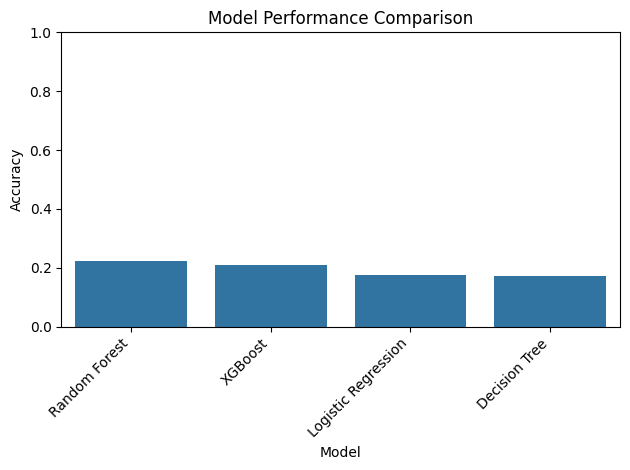

In [18]:
# Create a DataFrame to store model performance
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

# Sort results by accuracy
results = results.sort_values(by='Accuracy', ascending=False)

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Performance Comparison')
plt.ylim(0, 1) # Set y-axis limit for accuracy
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Choosing Best Performing** **Model**

In [19]:
# Based on Model Performance Comparison, using the Random Forest as the best performer.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300], # Added 300 for more options
    'max_depth': [5, 10, 15, None], # Added 15 for more options
    'min_samples_split': [2, 5, 10] # Added 10 for more options
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,  # use all CPU cores
    verbose=1
)

# Using the SMOTE-balanced training data
grid_search.fit(X_train_smote, y_train_smote)
best_model = grid_search.best_estimator_

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best F1 score (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best F1 score (CV): 0.2518


**Visualizing Confusion Metrix for Random Forest Classifier**

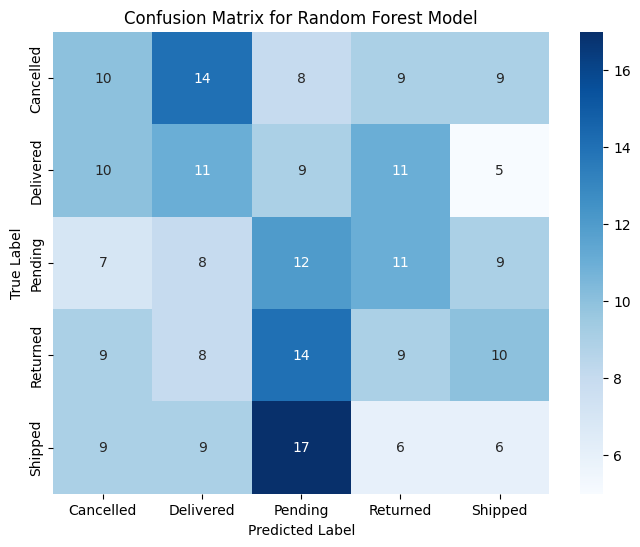

In [20]:
# Predict on the test set using the best model
best_model_pred = best_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, best_model_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()